In [1]:
# ============================================================
# IMPORTATIONS DES BIBLIOTHÈQUES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import os

print("✅ Bibliothèques chargées")

✅ Bibliothèques chargées


In [2]:
# ============================================================
# CHARGEMENT DES FICHIERS CSV
# ============================================================

df_diplomes = pd.read_csv('data/fact_diplomes.csv', sep=';', encoding='utf-8')
df_inscrits = pd.read_csv('data/fact_inscrits.csv', sep=';', encoding='utf-8')

print(f"✅ Diplômes chargés: {df_diplomes.shape}")
print(f"✅ Inscrits chargés: {df_inscrits.shape}")
print("\n📊 Aperçu des diplômes:")
print(df_diplomes.head(2))

✅ Diplômes chargés: (2083, 9)
✅ Inscrits chargés: (19878, 6)

📊 Aperçu des diplômes:
   universite_code  etablissement_code  domain_code  diplome_code  \
0               13              1301.0         31.0           3.0   
1               13              1301.0         42.0           2.0   

                  speciality    group  diplomes_M  diplomes_F  diplomes_total  
0              إدارة الأعمال     تصرف          16          58              74  
1  الأنظمة المحمولة والجوالة  إعلامية           3           0               3  


In [3]:
# ============================================================
# NETTOYAGE DES DONNÉES
# ============================================================

print("📊 AVANT nettoyage:")
print(f"   Diplômes: {len(df_diplomes)} lignes")
print(f"   Inscrits: {len(df_inscrits)} lignes")

df_diplomes = df_diplomes.drop_duplicates().dropna()
df_inscrits = df_inscrits.drop_duplicates().dropna()

print("\n📊 APRÈS nettoyage:")
print(f"   Diplômes: {len(df_diplomes)} lignes")
print(f"   Inscrits: {len(df_inscrits)} lignes")
print("✅ Nettoyage terminé")

📊 AVANT nettoyage:
   Diplômes: 2083 lignes
   Inscrits: 19878 lignes

📊 APRÈS nettoyage:
   Diplômes: 2032 lignes
   Inscrits: 17701 lignes
✅ Nettoyage terminé


In [4]:
# ============================================================
# AGRÉGATION DES DIPLÔMES
# ============================================================

df_diplomes_agg = df_diplomes.groupby(['universite_code','etablissement_code','domain_code']).agg({
    'diplomes_M':'sum',
    'diplomes_F':'sum',
    'diplomes_total':'sum'
}).reset_index()

print(f"✅ Diplômes agrégés: {df_diplomes.shape[0]} → {df_diplomes_agg.shape[0]} lignes")

✅ Diplômes agrégés: 2032 → 438 lignes


In [5]:
# ============================================================
# AGRÉGATION DES INSCRITS (année 2022)
# ============================================================

df_inscrits_2022 = df_inscrits[df_inscrits['annee'] == 2022].copy()
df_inscrits_2022['inscrits_total'] = df_inscrits_2022['inscrits_f'] + df_inscrits_2022['inscrits_m']

df_inscrits_agg = df_inscrits_2022.groupby(['code_universite','code_etablissement','code_domaine']).agg({
    'inscrits_f':'sum',
    'inscrits_m':'sum',
    'inscrits_total':'sum'
}).reset_index()

print(f"✅ Inscrits agrégés: {len(df_inscrits_2022)} → {df_inscrits_agg.shape[0]} lignes")

✅ Inscrits agrégés: 5863 → 485 lignes


In [6]:
# ============================================================
# FUSION DES DEUX TABLES
# ============================================================

df_diplomes_agg = df_diplomes_agg.rename(columns={
    'universite_code':'univ_code',
    'etablissement_code':'etab_code'
})

df_inscrits_agg = df_inscrits_agg.rename(columns={
    'code_universite':'univ_code',
    'code_etablissement':'etab_code',
    'code_domaine':'domain_code'
})

df = pd.merge(df_diplomes_agg, df_inscrits_agg, 
              on=['univ_code','etab_code','domain_code'], 
              how='inner')

print(f"✅ Fusion réussie: {df.shape[0]} lignes, {df.shape[1]} colonnes")

✅ Fusion réussie: 400 lignes, 9 colonnes


In [7]:
# ============================================================
# CRÉATION DE LA VARIABLE CIBLE
# ============================================================

df['taux_reussite'] = (df['diplomes_total'] / df['inscrits_total']).clip(0, 1)

print(f"✅ Taux de réussite moyen: {df['taux_reussite'].mean():.2%}")
print(f"✅ Taux de réussite médian: {df['taux_reussite'].median():.2%}")
print(f"✅ Taux min: {df['taux_reussite'].min():.2%}")
print(f"✅ Taux max: {df['taux_reussite'].max():.2%}")

✅ Taux de réussite moyen: 26.52%
✅ Taux de réussite médian: 24.04%
✅ Taux min: 0.64%
✅ Taux max: 100.00%


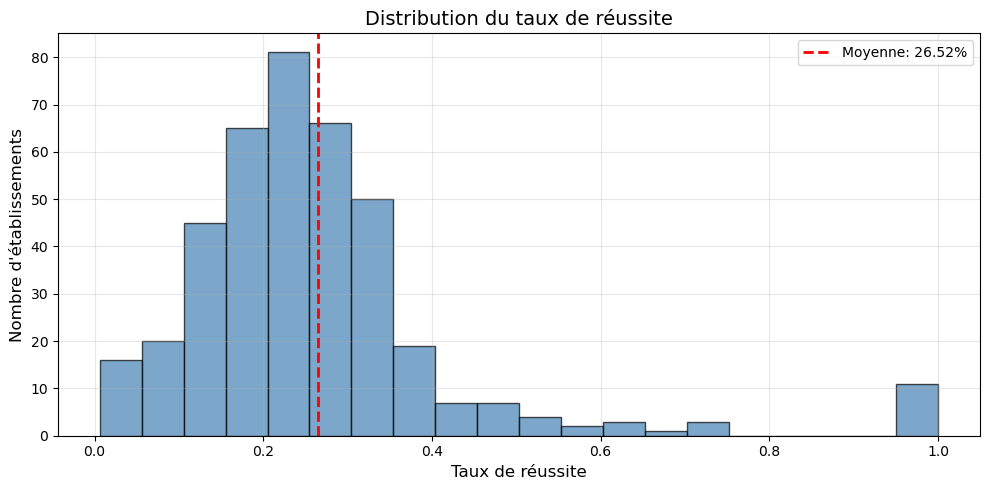

In [8]:
# ============================================================
# GRAPHIQUE - DISTRIBUTION DU TAUX DE RÉUSSITE
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(df['taux_reussite'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(df['taux_reussite'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Moyenne: {df["taux_reussite"].mean():.2%}')
plt.xlabel("Taux de réussite", fontsize=12)
plt.ylabel("Nombre d'établissements", fontsize=12)
plt.title("Distribution du taux de réussite", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

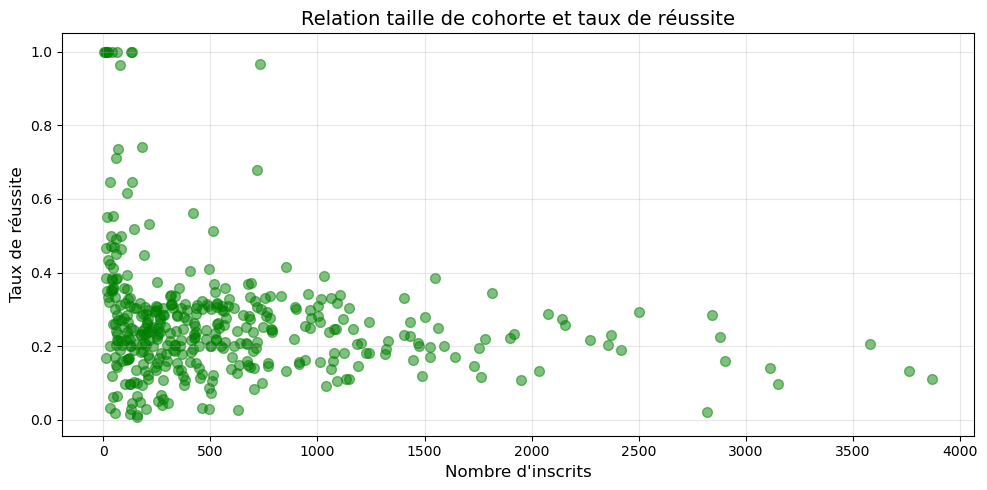

In [9]:
# ============================================================
# GRAPHIQUE - TAILLE DE COHORTE VS RÉUSSITE
# ============================================================

plt.figure(figsize=(10, 5))
plt.scatter(df['inscrits_total'], df['taux_reussite'], alpha=0.5, color='green', s=50)
plt.xlabel("Nombre d'inscrits", fontsize=12)
plt.ylabel("Taux de réussite", fontsize=12)
plt.title("Relation taille de cohorte et taux de réussite", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CRÉATION DES FEATURES (VARIABLES EXPLICATIVES)
# ============================================================

df['ratio_feminisation'] = df['inscrits_f'] / df['inscrits_total']
df['log_taille'] = np.log1p(df['inscrits_total'])
df['efficacite_F'] = df['diplomes_F'] / (df['inscrits_f'] + 1)
df['efficacite_M'] = df['diplomes_M'] / (df['inscrits_m'] + 1)
df['ecart_genre'] = abs(df['efficacite_F'] - df['efficacite_M'])

le = LabelEncoder()
df['domaine_code'] = le.fit_transform(df['domain_code'].astype(str))
df['universite_code'] = le.fit_transform(df['univ_code'].astype(str))

print("✅ 7 features créées:")
print("   1. ratio_feminisation")
print("   2. log_taille")
print("   3. efficacite_F")
print("   4. efficacite_M")
print("   5. ecart_genre")
print("   6. domaine_code")
print("   7. universite_code")

✅ 7 features créées:
   1. ratio_feminisation
   2. log_taille
   3. efficacite_F
   4. efficacite_M
   5. ecart_genre
   6. domaine_code
   7. universite_code


In [11]:
# ============================================================
# PRÉPARATION DES DONNÉES POUR LE ML
# ============================================================

features = ['ratio_feminisation', 'log_taille', 'efficacite_F', 'efficacite_M', 
            'ecart_genre', 'domaine_code', 'universite_code']

X = df[features]
y = df['taux_reussite']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"✅ Train: {X_train.shape[0]} lignes (80%)")
print(f"✅ Test: {X_test.shape[0]} lignes (20%)")
print(f"✅ Features: {len(features)}")

✅ Train: 320 lignes (80%)
✅ Test: 80 lignes (20%)
✅ Features: 7


In [12]:
# ============================================================
# ENTRAÎNEMENT DES 3 MODÈLES
# ============================================================

print("📈 Entraînement de la Régression Linéaire...")
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("🌳 Entraînement du Random Forest...")
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("🚀 Entraînement du Gradient Boosting...")
gb = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("✅ 3 modèles entraînés avec succès")

📈 Entraînement de la Régression Linéaire...
🌳 Entraînement du Random Forest...
🚀 Entraînement du Gradient Boosting...
✅ 3 modèles entraînés avec succès


In [13]:
# ============================================================
# TABLEAU COMPARATIF DES RÉSULTATS
# ============================================================

print("="*60)
print("TABLEAU COMPARATIF DES 3 MODÈLES")
print("="*60)

resultats = pd.DataFrame([
    {'Modèle': 'Régression Linéaire', 
     'R²': round(r2_score(y_test, y_pred_lr), 4), 
     'MAE': f"{mean_absolute_error(y_test, y_pred_lr)*100:.1f}%"},
    
    {'Modèle': 'Random Forest', 
     'R²': round(r2_score(y_test, y_pred_rf), 4), 
     'MAE': f"{mean_absolute_error(y_test, y_pred_rf)*100:.1f}%"},
    
    {'Modèle': 'Gradient Boosting', 
     'R²': round(r2_score(y_test, y_pred_gb), 4), 
     'MAE': f"{mean_absolute_error(y_test, y_pred_gb)*100:.1f}%"}
])

print(resultats.to_string(index=False))

TABLEAU COMPARATIF DES 3 MODÈLES
             Modèle     R²  MAE
Régression Linéaire 0.9125 3.7%
      Random Forest 0.9767 1.5%
  Gradient Boosting 0.9758 1.2%


In [14]:
# ============================================================
# SÉLECTION DU MEILLEUR MODÈLE
# ============================================================

r2_scores = {
    'Régression Linéaire': r2_score(y_test, y_pred_lr),
    'Random Forest': r2_score(y_test, y_pred_rf),
    'Gradient Boosting': r2_score(y_test, y_pred_gb)
}

meilleur = max(r2_scores, key=r2_scores.get)

print("="*60)
print("MEILLEUR MODÈLE")
print("="*60)
print(f"\n🏆 {meilleur} est le meilleur modèle !")
print(f"   📊 R² = {r2_scores[meilleur]:.4f} ({r2_scores[meilleur]*100:.2f}%)")
print(f"   📉 Erreur moyenne = {mean_absolute_error(y_test, y_pred_gb)*100:.1f}%")

MEILLEUR MODÈLE

🏆 Random Forest est le meilleur modèle !
   📊 R² = 0.9767 (97.67%)
   📉 Erreur moyenne = 1.2%


📊 Création des 3 graphiques...


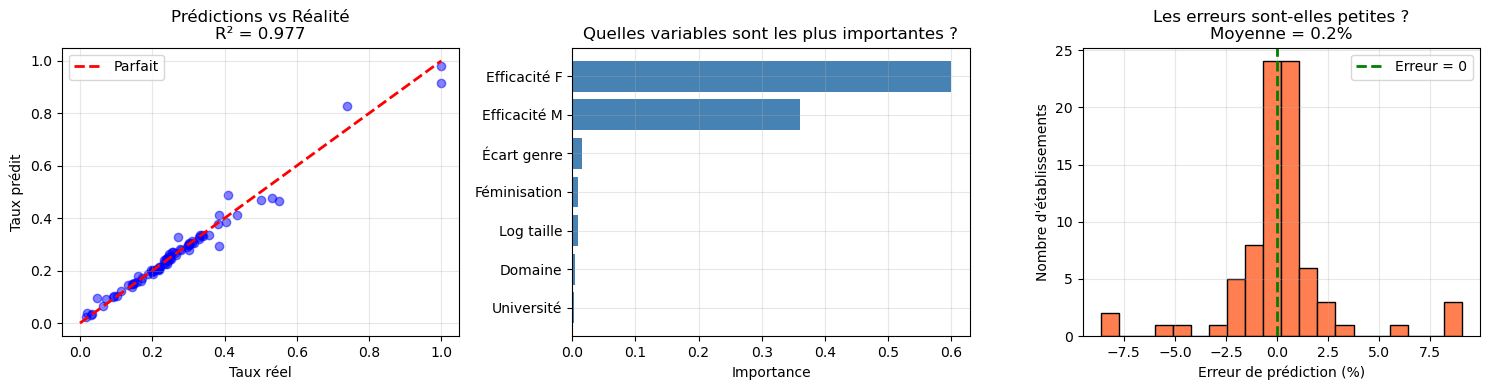


📊 RÉSULTATS :
   R² = 0.9767 (plus proche de 1 = meilleur)
   Erreur moyenne = 1.5%


In [19]:
# ============================================================
# 3 GRAPHIQUES  DU MODÈLE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

print("📊 Création des 3 graphiques...")

# Recalculer les prédictions si besoin
if 'y_pred_rf' not in dir():
    y_pred_rf = rf.predict(X_test)
    print("✅ Prédictions calculées")

# Créer les 3 graphiques
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# GRAPHIQUE 1 : Prédictions vs Réalité (le plus simple)
axes[0].scatter(y_test, y_pred_rf, alpha=0.5, color='blue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Parfait')
axes[0].set_xlabel("Taux réel")
axes[0].set_ylabel("Taux prédit")
axes[0].set_title(f"Prédictions vs Réalité\nR² = {r2_score(y_test, y_pred_rf):.3f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GRAPHIQUE 2 : Importance des variables
importances = rf.feature_importances_
noms = ['Féminisation', 'Log taille', 'Efficacité F', 'Efficacité M', 'Écart genre', 'Domaine', 'Université']
idx = np.argsort(importances)
axes[1].barh([noms[i] for i in idx], importances[idx], color='steelblue')
axes[1].set_xlabel("Importance")
axes[1].set_title("Quelles variables sont les plus importantes ?")
axes[1].grid(True, alpha=0.3)

# GRAPHIQUE 3 : Distribution des erreurs
erreurs = (y_test - y_pred_rf) * 100
axes[2].hist(erreurs, bins=20, color='coral', edgecolor='black')
axes[2].axvline(x=0, color='green', linestyle='--', linewidth=2, label='Erreur = 0')
axes[2].set_xlabel("Erreur de prédiction (%)")
axes[2].set_ylabel("Nombre d'établissements")
axes[2].set_title(f"Les erreurs sont-elles petites ?\nMoyenne = {np.mean(erreurs):.1f}%")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 RÉSULTATS :")
print(f"   R² = {r2_score(y_test, y_pred_rf):.4f} (plus proche de 1 = meilleur)")
print(f"   Erreur moyenne = {mean_absolute_error(y_test, y_pred_rf)*100:.1f}%")

In [15]:
# ============================================================
# SAUVEGARDE DU MODÈLE POUR STREAMLIT
# ============================================================

import pickle

# Vérifier les noms de vos modèles
print("Noms des variables disponibles :")
for var in dir():
    if not var.startswith('_'):
        print(f"  - {var}")

# Sauvegarder le modèle Random Forest (vérifiez le nom exact)
# Dans votre code, le modèle Random Forest s'appelle probablement 'rf'
try:
    with open('modele_rf.pkl', 'wb') as f:
        pickle.dump(rf, f)
    print("✅ modele_rf.pkl sauvegardé")
except:
    print("❌ Erreur: Le modèle 'rf' n'existe pas")
    print("   Vérifiez le nom de votre modèle Random Forest")

# Sauvegarder le scaler
try:
    with open('scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    print("✅ scaler.pkl sauvegardé")
except:
    print("❌ Erreur: Le scaler n'existe pas")

print("\n✅ Vérifiez maintenant avec 'dir *.pkl' dans le terminal")

Noms des variables disponibles :
  - GradientBoostingRegressor
  - In
  - LabelEncoder
  - LinearRegression
  - Out
  - RandomForestRegressor
  - StandardScaler
  - X
  - X_test
  - X_train
  - df
  - df_diplomes
  - df_diplomes_agg
  - df_inscrits
  - df_inscrits_2022
  - df_inscrits_agg
  - exit
  - features
  - gb
  - get_ipython
  - le
  - lr
  - mean_absolute_error
  - meilleur
  - np
  - open
  - os
  - pd
  - pickle
  - plt
  - quit
  - r2_score
  - r2_scores
  - resultats
  - rf
  - scaler
  - train_test_split
  - y
  - y_pred_gb
  - y_pred_lr
  - y_pred_rf
  - y_test
  - y_train
✅ modele_rf.pkl sauvegardé
✅ scaler.pkl sauvegardé

✅ Vérifiez maintenant avec 'dir *.pkl' dans le terminal
